# Show how nucleosome entropy is related to replication and gene expression level

May 14, 2024

**Goal:** Discern how nucleosome entropy is affected by:
1. Replication timing: early vs late
2. Gene expression, level and regulation


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.global_config import GlobalConstants

repl_timing = pd.read_csv(GlobalConstants.REPL_TIMING_FILEPATH).set_index('orf_name')
print(len(repl_timing), " genes with replication profiles")
repl_timing.head()

5250  genes with replication profiles


,timing,H_index
orf_name,,
YAL067W-A,53.314585,196
YAL067C,52.304185,194
YAL064C-A,52.809385,195
YAL064W,51.798985,193
YAL063C-A,51.798985,193


In [5]:
from src.promoter_ptr_analysis import PromoterPTRAnalysis

chromatin_dir = 'output/deconvolve_combined_g_opt_2024_03_14/chromatin/'
promoter_analysis = PromoterPTRAnalysis(chromatin_dir)
promoter_analysis.load_f_files()

Shape of the loaded F: (227, 200)
1/5574 - 00:00:00.045
1001/5574 - 00:00:05.845
2001/5574 - 00:00:11.801
3001/5574 - 00:00:17.770
4001/5574 - 00:00:23.801
5001/5574 - 00:00:29.773


In [6]:
promoter_analysis.correct_f_images_by_strand()

In [7]:
# Let's get the gene expression at the replication time.

from src.gene_expression_deconv_analysis import GeneExpressionAnalysis

ge_analysis = GeneExpressionAnalysis(
    'output/deconvolve_combined_g_opt_2024_03_14/gene_expression/')
ge_analysis.load_gene_expression_fs()


In [8]:
from src.gene_chromatin_replication_analysis import GeneChromatinReplicationAnalysis

gene_chrom_repl_analysis = GeneChromatinReplicationAnalysis(promoter_analysis,
                                                            ge_analysis,
                                                            repl_timing)

5232 genes with replication timing
Shape of the f images:  (5232, 227, 8, 25)


In [9]:
from src.helpers import calc_entropy

In [10]:
gene_chrom_repl_analysis.compute_gene_nuc_entropy()

Shape of the f images:  (5232, 227, 8, 25)
Shape of the bins to compute entropy over:  (5232, 128, 17)


/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/scipy/stats/_entropy.py:135: RuntimeWarning: invalid value encountered in divide
  pk = 1.0*pk / np.sum(pk, axis=axis, keepdims=True)


In [11]:
gene_chrom_repl_analysis.normalized_entropy_df.to_csv('output/normalized_gb_entropy.csv')

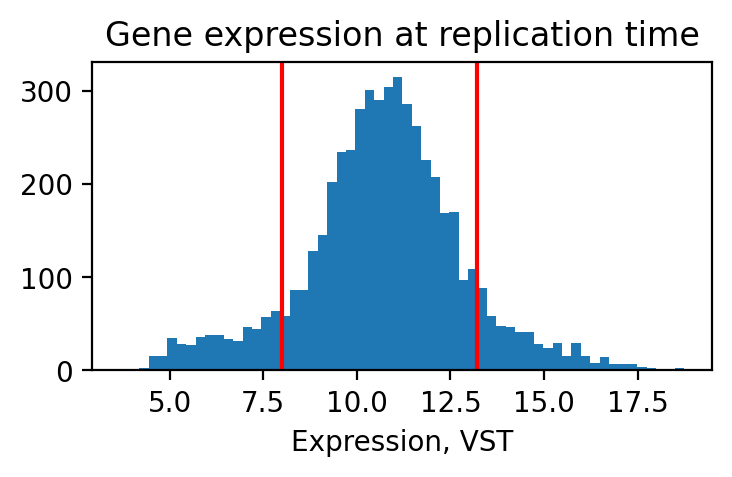

In [12]:
tx_repl = gene_chrom_repl_analysis.geneset_repl.expression_at_replication
plt.figure(figsize=(4, 2))
plt.hist(tx_repl, bins=60)
plt.title("Gene expression at replication time")
plt.xlabel("Expression, VST")

q25, q75 = np.quantile(tx_repl, q=[0.1, 0.9])

plt.axvline(q25, c='red')
plt.axvline(q75, c='red')

np.sum(tx_repl > q75), np.sum(tx_repl <  q25)

high_tx_orfs = tx_repl.loc[tx_repl > q75].index
low_tx_orfs = tx_repl.loc[tx_repl < q25].index

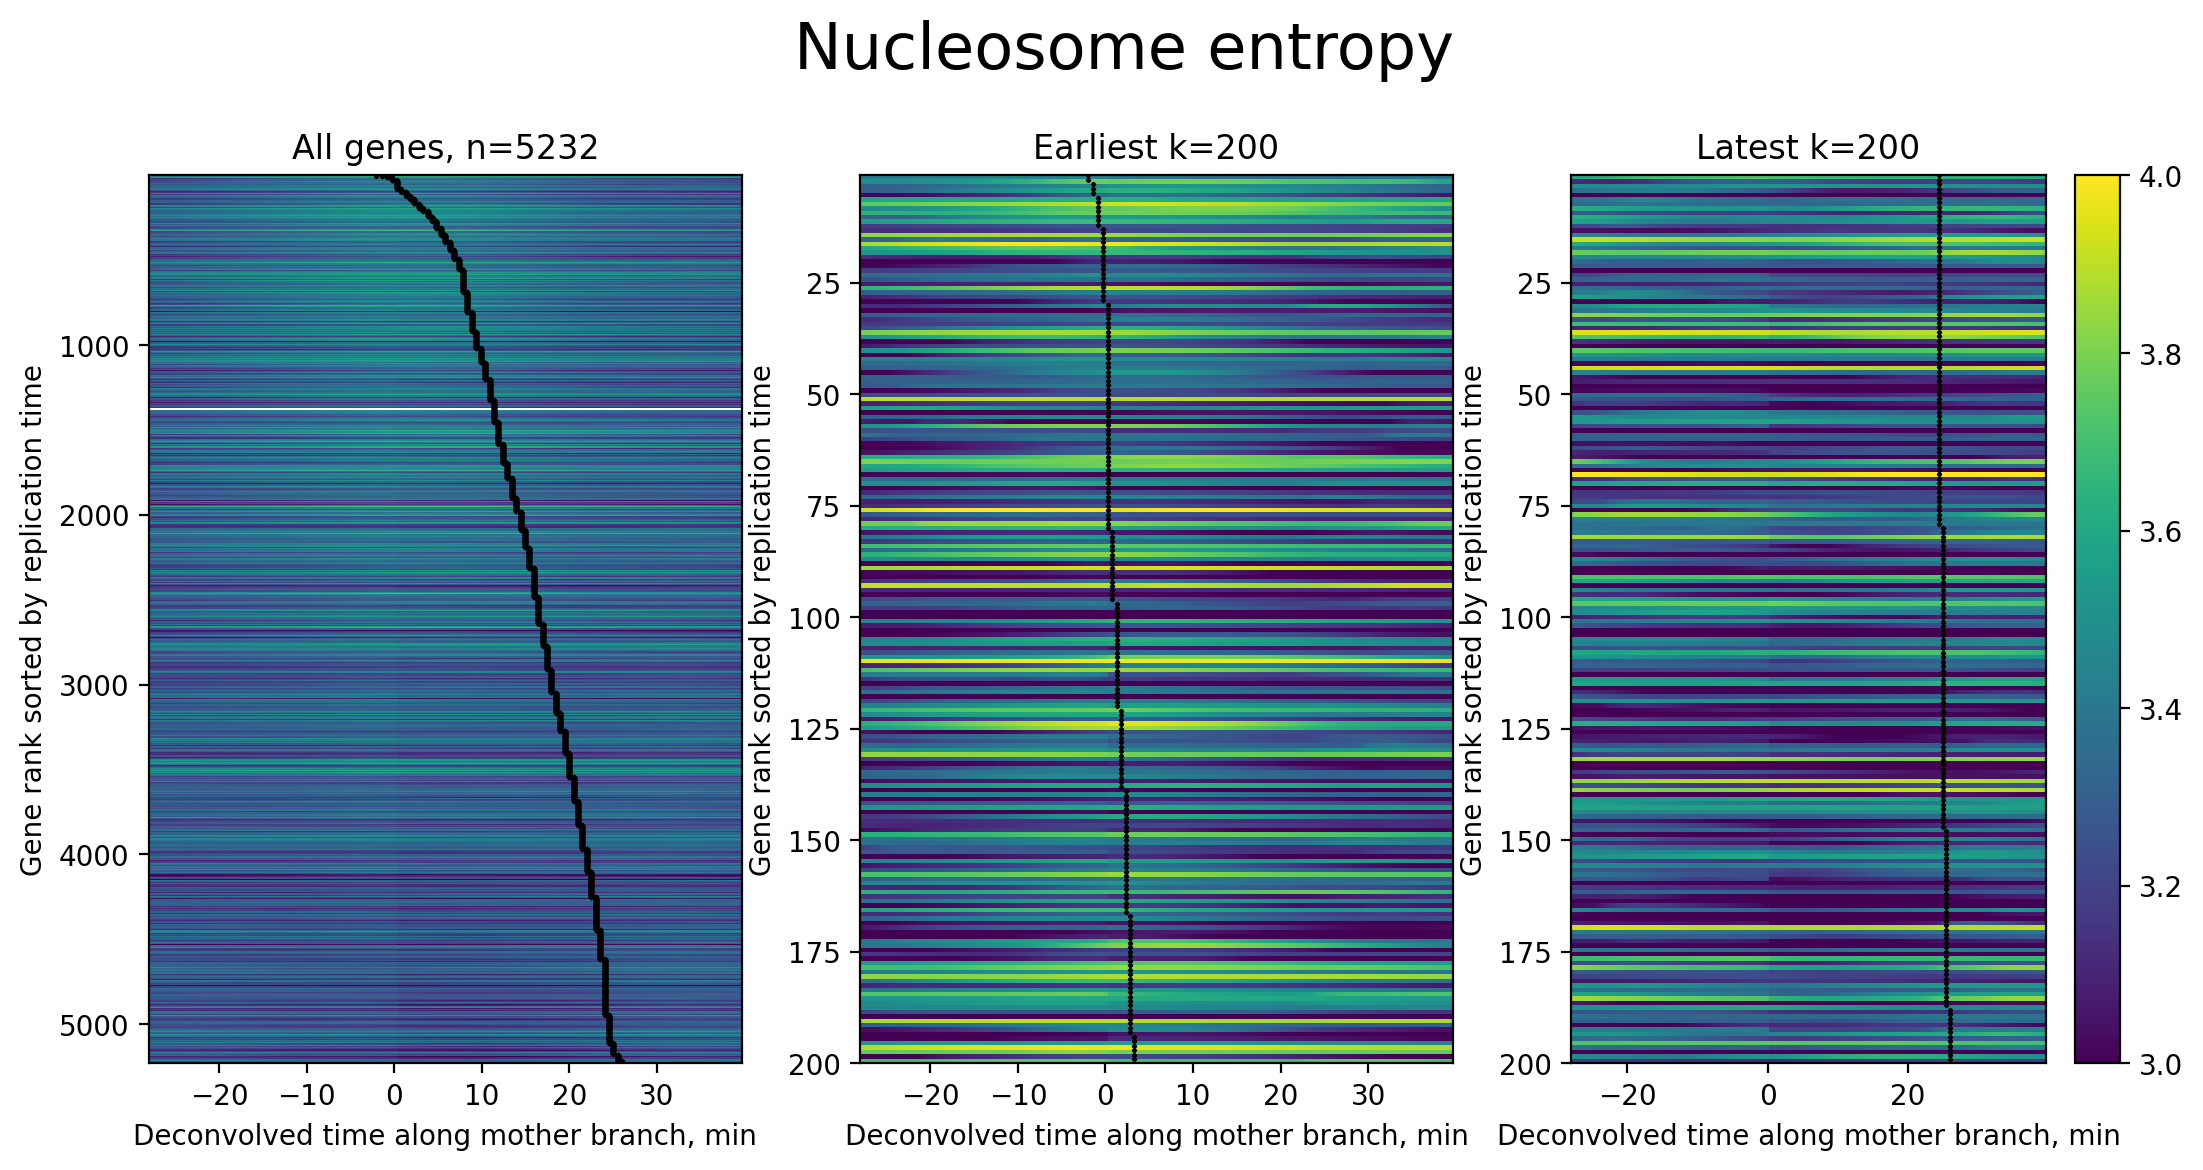

In [13]:
gene_chrom_repl_analysis.plot_early_late_entropy_hm_comparision(normalize=True)

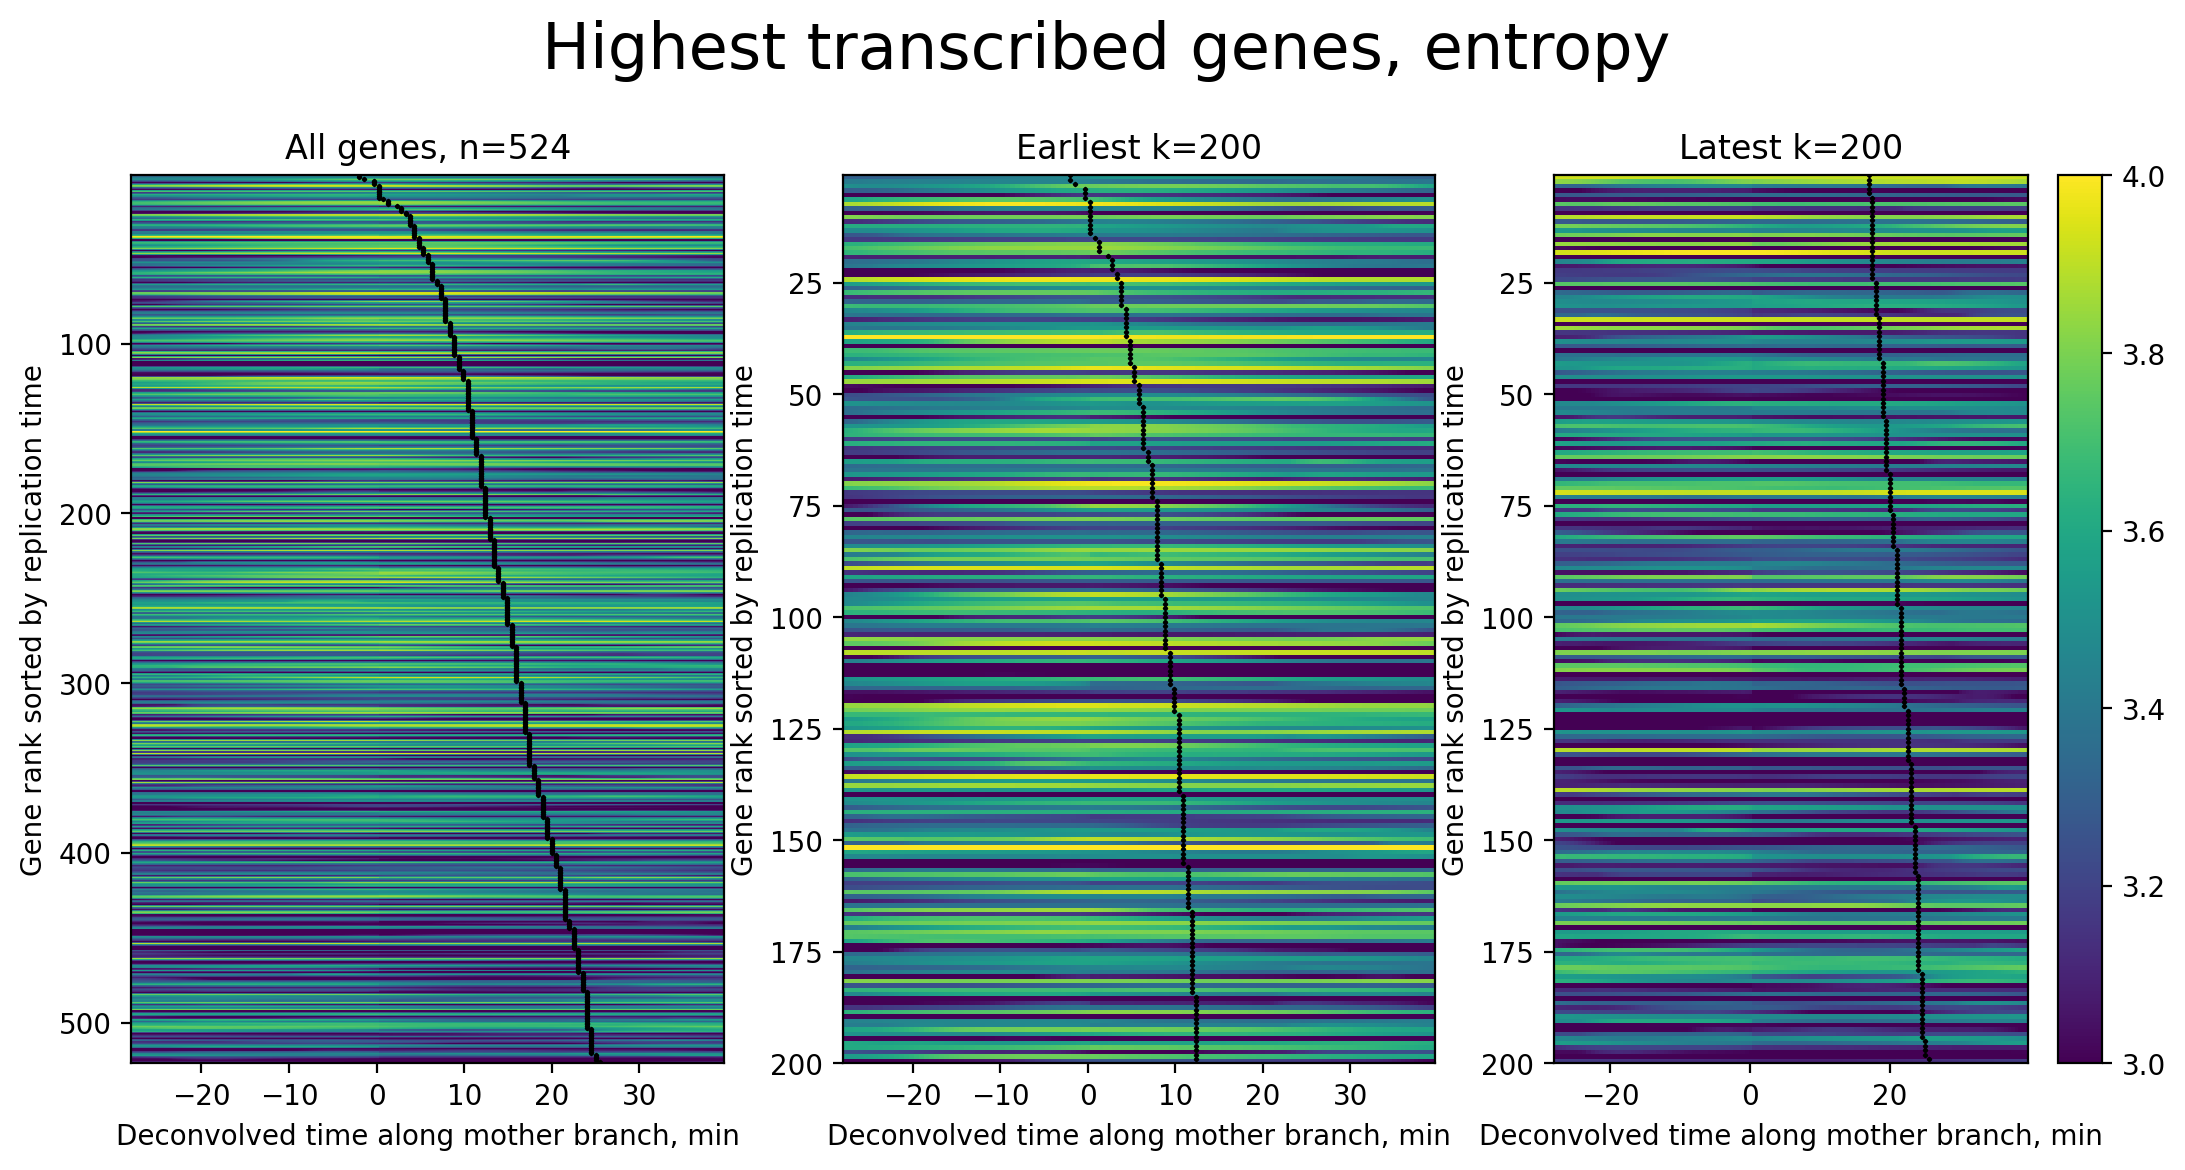

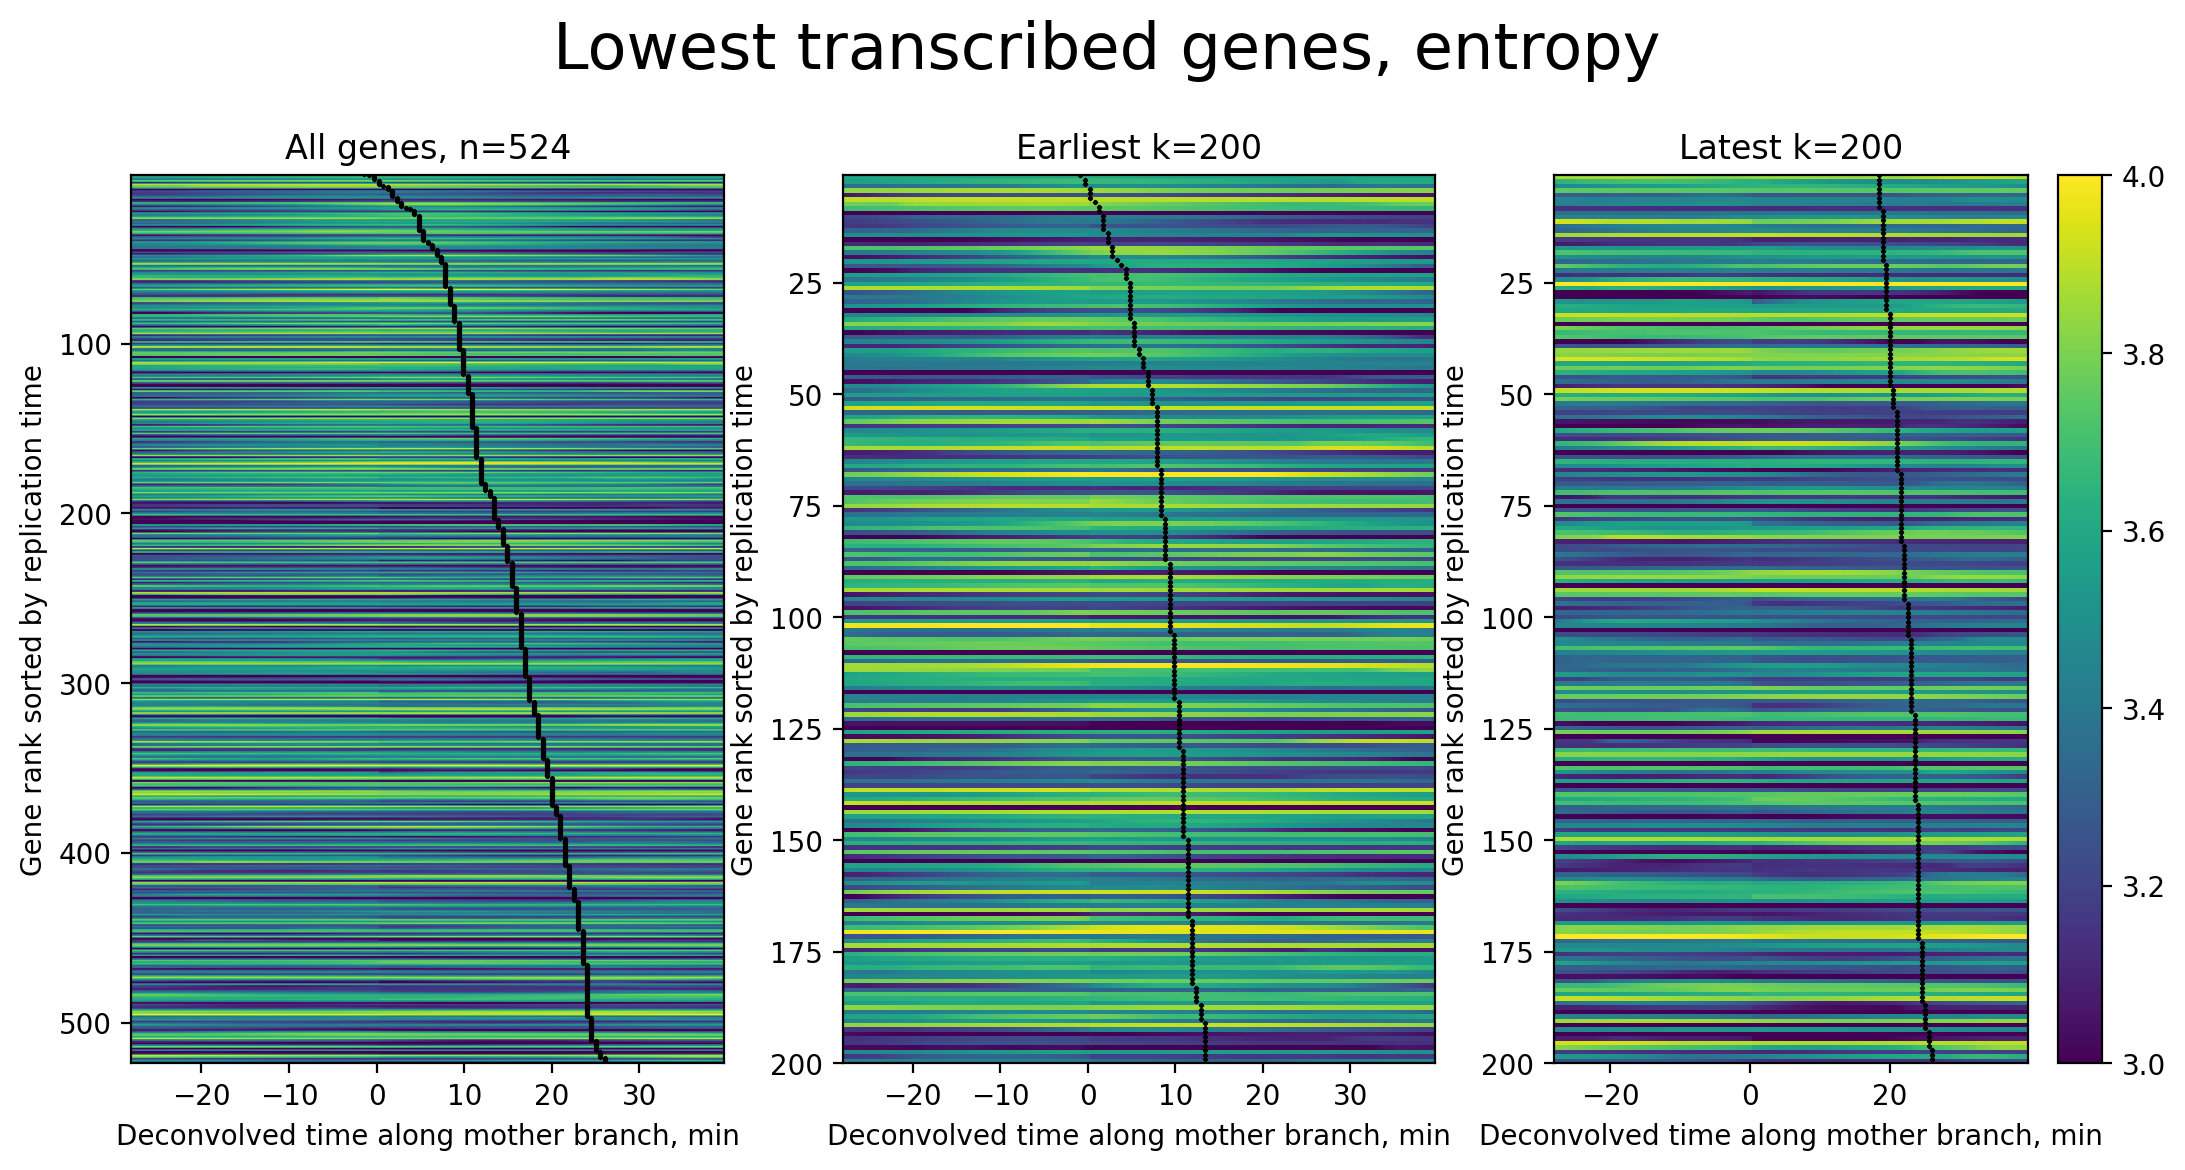

In [14]:
gene_chrom_repl_analysis.plot_early_late_entropy_hm_comparision(normalize=True,
    subset_orfs=high_tx_orfs, title="Highest transcribed genes, entropy")
gene_chrom_repl_analysis.plot_early_late_entropy_hm_comparision(normalize=True,
    subset_orfs=low_tx_orfs, title="Lowest transcribed genes, entropy")


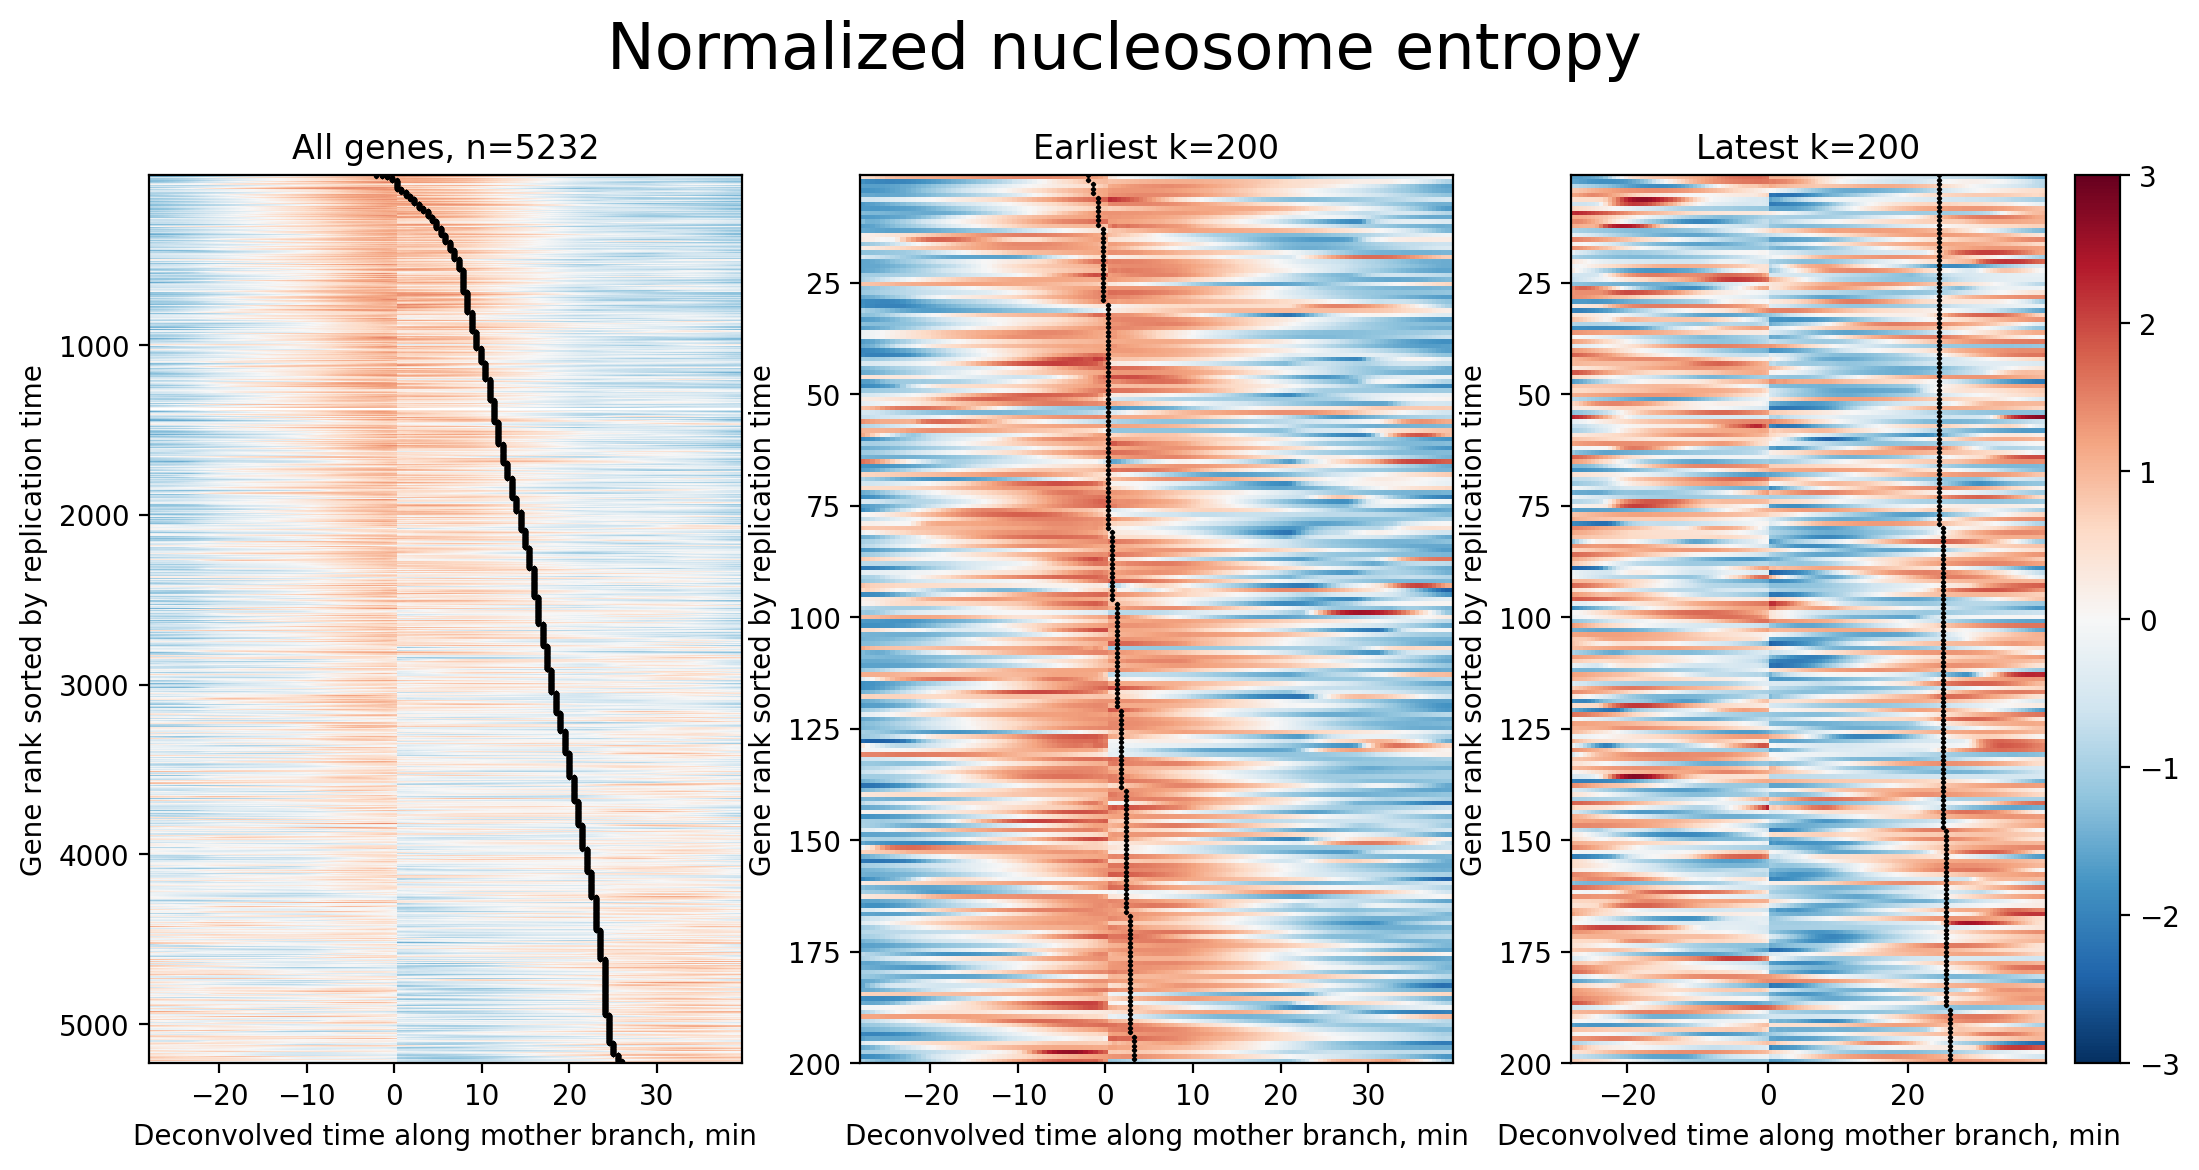

In [15]:
# In the unnormalized entropy scores, can we see a global effect of the replication fork
# passing through early and late genes?
gene_chrom_repl_analysis.plot_early_late_entropy_hm_comparision()


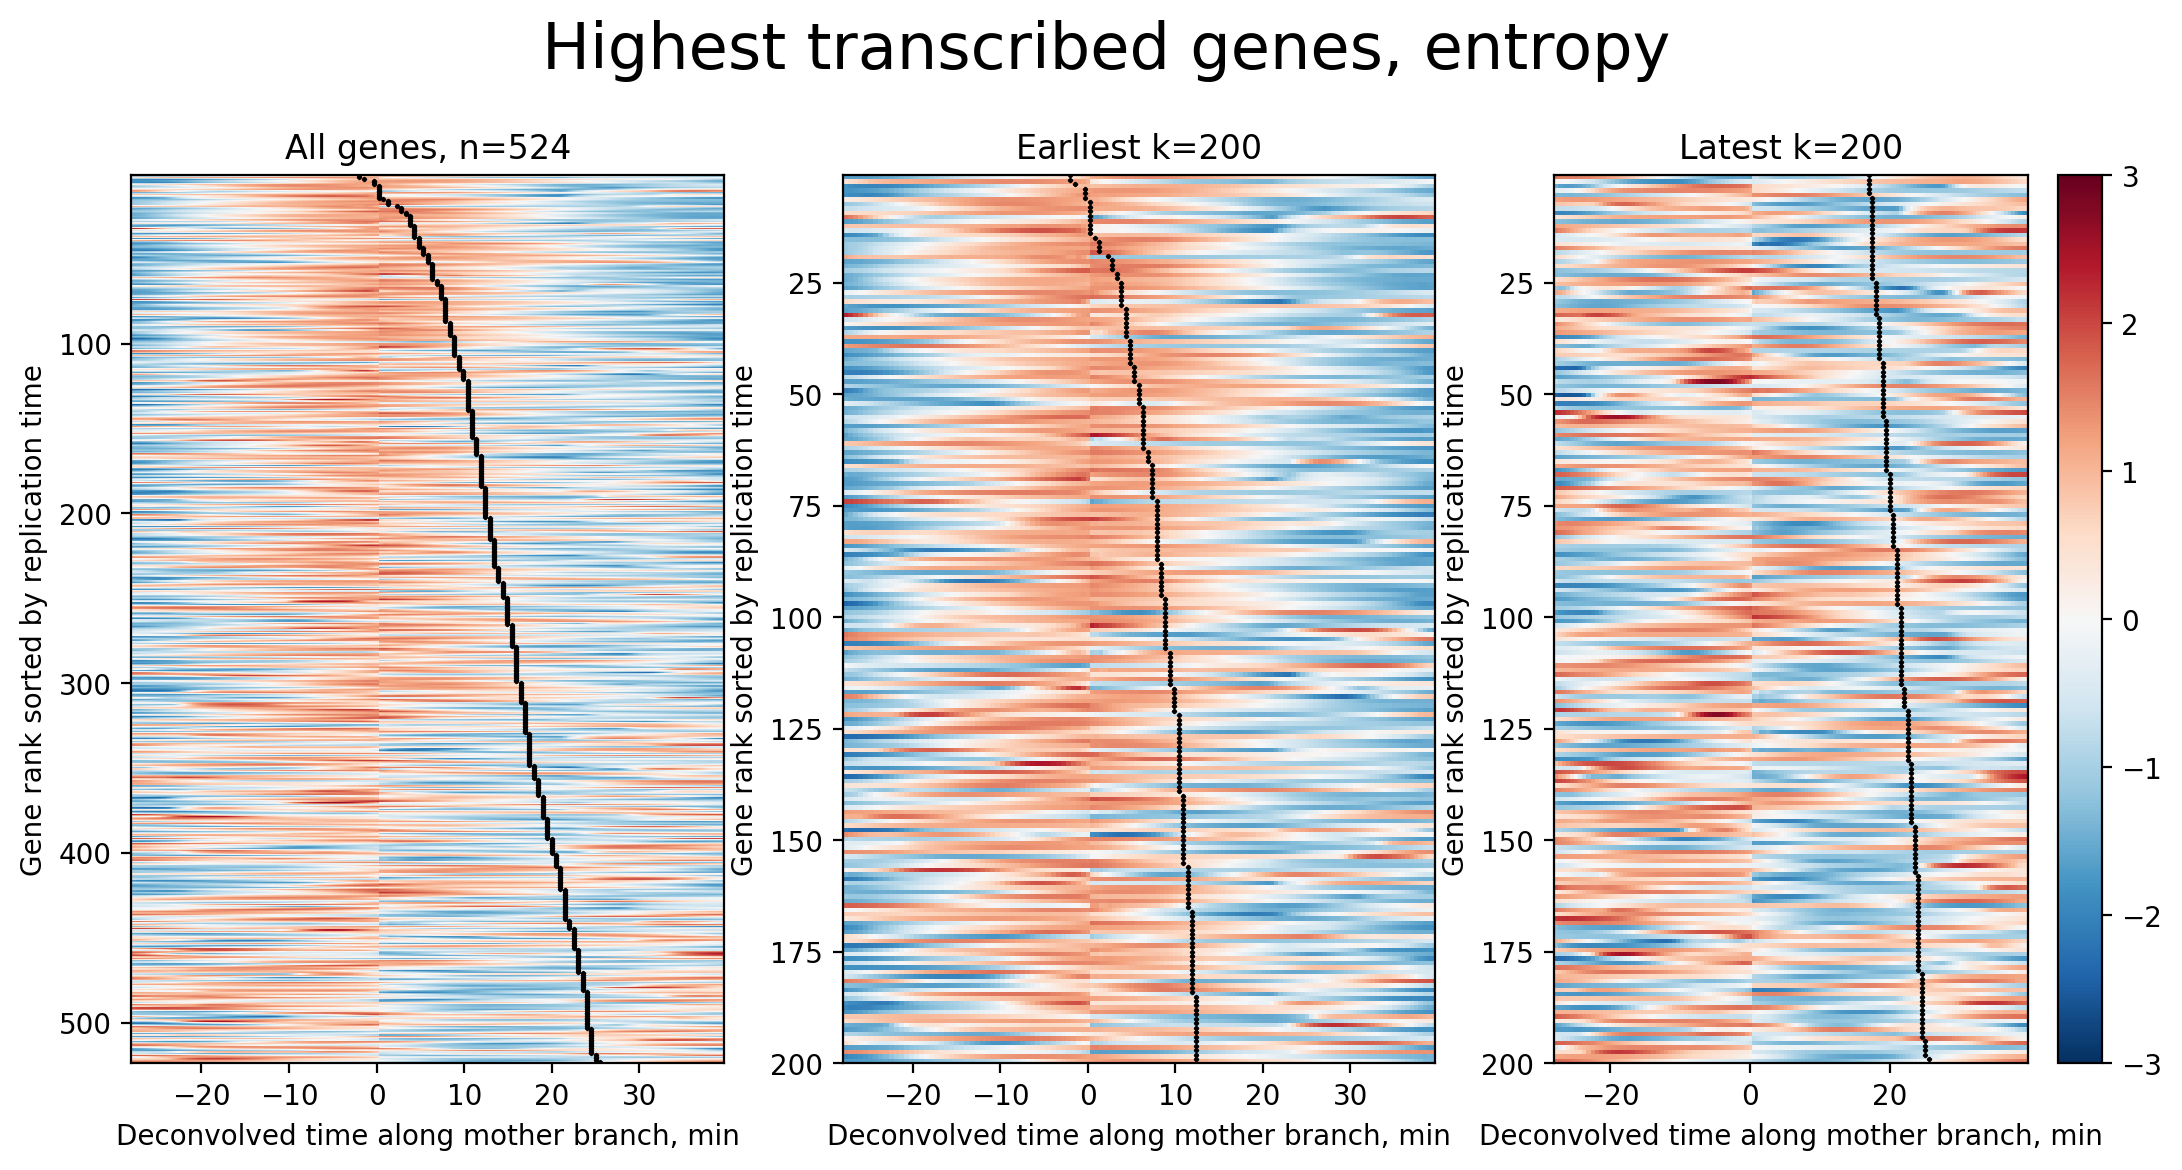

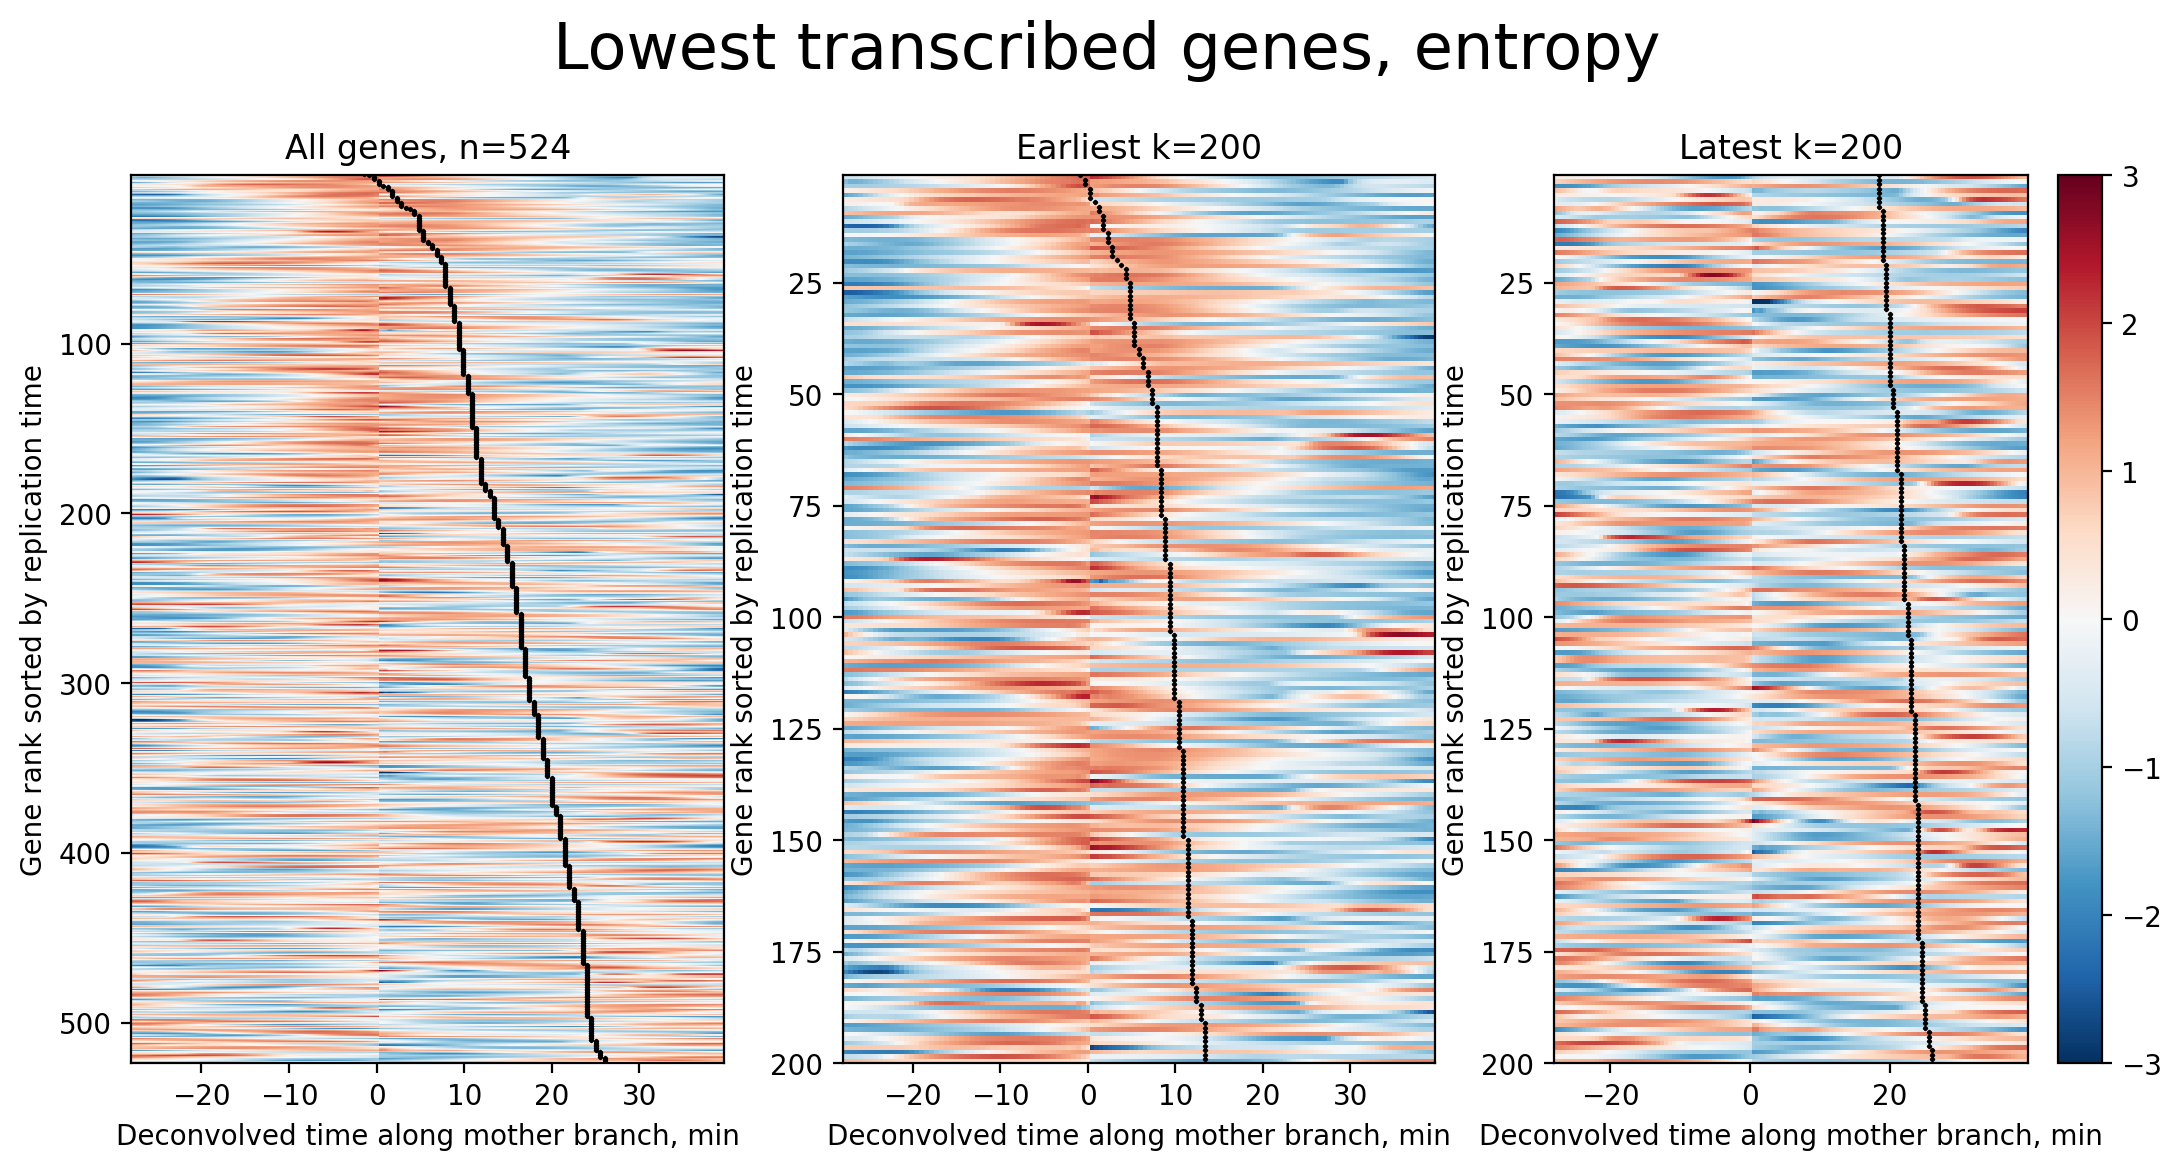

In [17]:
gene_chrom_repl_analysis.plot_early_late_entropy_hm_comparision(normalize=False,
    subset_orfs=high_tx_orfs, title="Highest transcribed genes, entropy")
gene_chrom_repl_analysis.plot_early_late_entropy_hm_comparision(normalize=False,
    subset_orfs=low_tx_orfs, title="Lowest transcribed genes, entropy")


# Analysis to work through absolute entropy values

Absolute entropy values make more sense and help us have an idea on the overall entropy across the genome. But the values span and oscillate along different entropy values making it difficult to identify patterns in oscillation for early vs late replicating genes without normalization.

If we want to avoid normalization, which may add an additional layer of complexity, we can try to break the entropy scores in to quantiles that make it easier to compare early and late replicating genes. 

**Idea:** Gene nucleosomes have different baseline levels of entropy (some sets of nucleosomes shift more than others). So let's split them up. Perhaps these are nucleosomes that more commonly pickup certain histone variants (possible side analysis).

**Hypothesis**: Genes with nucleosomes that are more entropic overall, have a differential timing of peak entropy alongside replication than nucleosomes with less entropy.

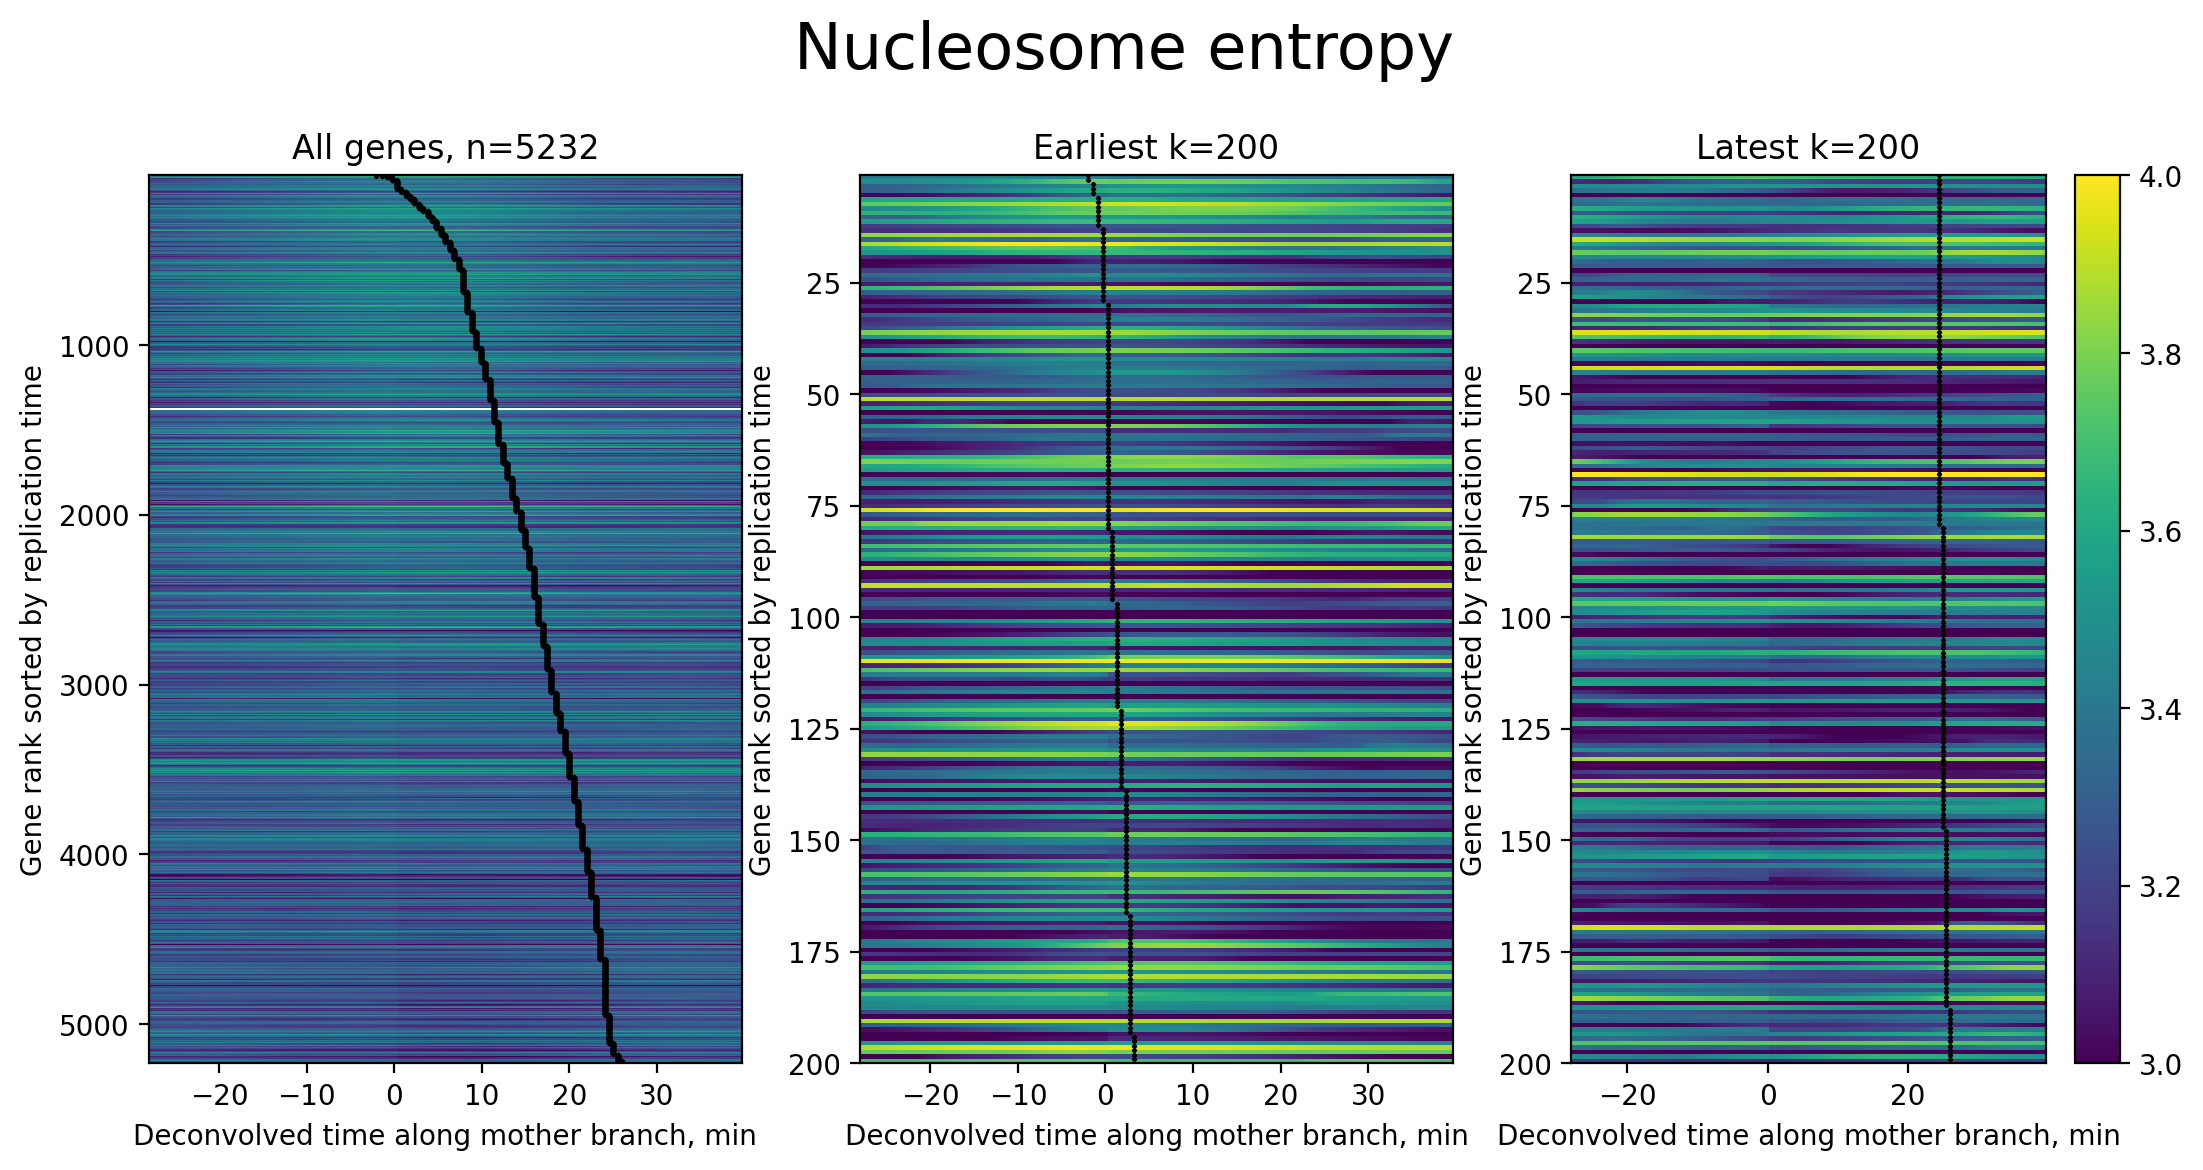

In [19]:
gene_chrom_repl_analysis.plot_early_late_entropy_hm_comparision(normalize=True)